# ADS1001 Project Report Notebook

## Which Weather Indicators Matter Most for Public Communication in Malaysia?

### Group Members

- **LI YIMING** — Member 1: Introduction, client problem and research questions
- **CHEN ZIMO** — Member 2: Dataset overview, data dictionary, data cleaning and feature engineering
- **HUANG QINGYUE** — Member 3: Outdoor comfort indicators
- **TAY CHEN ZHE** — Member 4: Public risk and warning indicators
- **XU ZIHAO** — Member 5: Overall recommendations, limitations and future work

### Theme and Domain
This project uses selected Malaysian weather records to help a public weather information service identify which indicators are most useful for public communication.

### Dataset Source
The project uses the provided ADS1001 Malaysia weather dataset and the weather data dictionary supplied in the project folder.

## 1. Title, Members & Theme

### Project Title
**Which Weather Indicators Matter Most for Public Communication in Malaysia?**

### Client
Our client is a **Malaysian public weather information service** that provides weather guidance to residents, commuters, outdoor users and event organisers.

### Client Problem
The client has access to many weather variables, such as temperature, humidity, dew point, pressure, wind speed, gust, UV index and precipitation. However, not all raw measurements are equally easy for the public to interpret or act on directly.

The client therefore needs evidence-based recommendations about which indicators should be prioritised for public-facing messages.

### Project Aim
To identify the most useful weather indicators for communicating:

- outdoor comfort;
- rainfall conditions;
- wind-related risk;
- UV exposure.

### Main Research Question
**Which weather indicators are most useful for communicating outdoor comfort, rainfall conditions, wind-related risk and UV exposure to the Malaysian public?**

## 2. Introduction & Research Questions

This project is not simply describing weather patterns. It evaluates the **public communication value** of weather indicators. For each indicator, we consider whether it is:

1. **Understandable** — can the public easily understand it?
2. **Actionable** — can the public take practical action based on it?
3. **Useful** — does it provide meaningful extra information beyond other indicators?
4. **Supported by the data** — is the data complete and reliable enough for the conclusion?

### Research Theme 1: Outdoor Comfort Indicators

Handled by Member 3.

1. **Does wind chill provide additional communication value beyond temperature in Malaysia's tropical climate?**
2. **How are humidity and dew point related, and which indicator is clearer for communicating uncomfortable or oppressive weather?**

### Research Theme 2: Public Risk and Warning Indicators

Handled by Member 4.

3. **Is pressure reliable enough to support public rainfall communication, or are precipitation measures more useful?**
4. **Does gust provide extra warning value beyond average wind speed?**
5. **How can standard UV index categories support clearer public UV warnings?**

## 3. Data Dictionary

The table below summarises the main variables used in this project. The exact column names come from the supplied CSV files.

| Variable | Meaning in this project | Used for |
|---|---|---|
| `temperature` | Air temperature | Outdoor comfort |
| `wind_chill` | Perceived temperature adjusted for wind | Temperature comparison |
| `humidity` | Relative humidity | Outdoor comfort |
| `dew_point` | Moisture / mugginess-related temperature | Outdoor comfort support |
| `pressure` | Atmospheric pressure | Rainfall context |
| `precipitation_rate` | Rate of rainfall | Rainfall communication |
| `precipitation_total` | Total precipitation amount | Rainfall communication |
| `wind_speed` | Average wind speed | Wind condition communication |
| `gust` | Sudden wind strength | Wind risk warning |
| `uv_index` | Ultraviolet exposure index | UV risk warning |
| `state`, `city`, `place` | Location fields | Coverage and representativeness |
| `year`, `month`, `day`, `hour`, `minutes`, `seconds` | Time fields | Datetime construction |

### Data Dictionary Mismatch
The data dictionary mentions air quality, but the available CSV does not include air quality variables. Therefore, this project cannot evaluate air-quality-related public weather communication.

## 4. Executive Summary

This notebook analyses selected Malaysian weather records to recommend the most useful public-facing weather indicators.

### Key Findings

- **Temperature** is clearer than wind chill for routine public comfort communication in Malaysia's tropical climate.
- **Humidity** is easier for the public to understand, while **dew point** can be used as a supporting technical indicator.
- **Precipitation** is clearer and more actionable than pressure for public rainfall communication.
- **Gust** adds warning value beyond average wind speed because it captures sudden wind increases.
- **UV index** is highly suitable for public warnings because it can be translated into standard risk categories.

### Final Recommendation
The client should prioritise **temperature, humidity, precipitation, wind speed, gust and UV index** for public communication. Technical indicators such as **wind chill, dew point and pressure** should be used as supporting or internal indicators rather than as the main public-facing message.

## 5. Data Loading

This section loads both the raw dataset and the cleaned dataset. Relative paths are used so the notebook can be run by other group members and markers without relying on a personal computer path.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

RAW_PATH = Path("malaysia_weather_raw.csv")
CLEANED_PATH = Path("malaysia_weather_cleaned_final.csv")

if not RAW_PATH.exists():
    raise FileNotFoundError("malaysia_weather_raw.csv was not found in the notebook folder.")
if not CLEANED_PATH.exists():
    raise FileNotFoundError("malaysia_weather_cleaned_final.csv was not found in the notebook folder.")

raw_weather = pd.read_csv(RAW_PATH)
weather = pd.read_csv(CLEANED_PATH)

print("Raw dataset shape:", raw_weather.shape)
print("Cleaned dataset shape:", weather.shape)

display(raw_weather.head())
display(weather.head())

Raw dataset shape: (57475, 19)
Cleaned dataset shape: (51693, 38)


,place,city,state,temperature,pressure,dew_point,humidity,wind_speed,gust,wind_chill,uv_index,precipitation_rate,precipitation_total,year,month,day,hour,minutes,seconds
0,Bandar Sri Permaisuri,Kuala Lumpur,Kuala Lumpur,30.3,1015.325,25.1,73.7,0.9,1.5,30.3,1.0,0.0,0.00,2022,Sep,23,13,54,57
1,Ampang Jaya,Kuala Lumpur,Kuala Lumpur,27.0,1000.680,25.6,92.0,5.2,5.3,27.0,0.0,0.0,17.78,2023,May,4,19,9,59
2,Bukit Jalil,Kuala Lumpur,Kuala Lumpur,26.4,1013.550,26.3,99.0,0.0,0.0,26.4,NaN,0.0,32.00,2021,Oct,23,23,44,43
3,Bukit Jalil,Kuala Lumpur,Kuala Lumpur,31.1,1005.420,30.9,99.0,0.0,0.0,31.1,NaN,0.0,0.00,2021,Mar,21,18,9,47
4,Penang Road,George Town,Pulau Pinang,25.8,1007.790,23.9,88.0,6.4,16.1,25.8,NaN,0.0,0.00,2022,Dec,22,7,0,23


,place,city,state,temperature,pressure,dew_point,humidity,wind_speed,gust,wind_chill,uv_index,precipitation_rate,precipitation_total,year,month,day,hour,minutes,seconds,temperature_was_imputed,pressure_was_imputed,dew_point_was_imputed,humidity_was_imputed,wind_speed_was_imputed,gust_was_imputed,wind_chill_was_imputed,uv_index_was_imputed,precipitation_rate_was_imputed,precipitation_total_was_imputed,month_number,datetime,temperature_difference,gust_difference,rain_event,pressure_change,falling_pressure,uv_category,high_uv
0,Air Itam,Timur Laut,Pulau Pinang,19.4,1010.33,8.9,50.8,0.0,0.0,19.4,0.0,0.0,34.29,2019,Dec,26,17,49,49,False,False,False,False,False,False,False,False,False,False,12,2019-12-26 17:49:49,0.0,0.0,True,NaN,False,Low,False
1,Air Itam,Timur Laut,Pulau Pinang,19.4,1011.01,11.6,60.5,0.0,0.0,19.4,0.0,0.0,34.29,2019,Dec,26,19,39,58,False,False,False,False,False,False,False,False,False,False,12,2019-12-26 19:39:58,0.0,0.0,True,0.68,False,Low,False
2,Air Itam,Timur Laut,Pulau Pinang,19.4,1011.51,11.3,59.3,0.0,0.0,19.4,0.0,0.0,34.29,2019,Dec,26,20,29,50,False,False,False,False,False,False,False,False,False,False,12,2019-12-26 20:29:50,0.0,0.0,True,0.50,False,Low,False
3,Air Itam,Timur Laut,Pulau Pinang,19.6,1011.85,12.0,61.3,0.0,0.0,19.6,0.0,0.0,34.29,2019,Dec,26,20,49,50,False,False,False,False,False,False,False,False,False,False,12,2019-12-26 20:49:50,0.0,0.0,True,0.34,False,Low,False
4,Air Itam,Timur Laut,Pulau Pinang,19.3,1012.70,10.4,56.5,0.0,0.0,19.3,0.0,0.0,0.00,2019,Dec,27,0,54,48,False,False,False,False,False,False,False,False,False,False,12,2019-12-27 00:54:48,0.0,0.0,False,0.85,False,Low,False


In [2]:
print("Raw data columns:")
print(list(raw_weather.columns))

print("\nCleaned data columns:")
print(list(weather.columns))

print("\nCleaned data info:")
weather.info()

Raw data columns:
['place', 'city', 'state', 'temperature', 'pressure', 'dew_point', 'humidity', 'wind_speed', 'gust', 'wind_chill', 'uv_index', 'precipitation_rate', 'precipitation_total', 'year', 'month', 'day', 'hour', 'minutes', 'seconds']

Cleaned data columns:
['place', 'city', 'state', 'temperature', 'pressure', 'dew_point', 'humidity', 'wind_speed', 'gust', 'wind_chill', 'uv_index', 'precipitation_rate', 'precipitation_total', 'year', 'month', 'day', 'hour', 'minutes', 'seconds', 'temperature_was_imputed', 'pressure_was_imputed', 'dew_point_was_imputed', 'humidity_was_imputed', 'wind_speed_was_imputed', 'gust_was_imputed', 'wind_chill_was_imputed', 'uv_index_was_imputed', 'precipitation_rate_was_imputed', 'precipitation_total_was_imputed', 'month_number', 'datetime', 'temperature_difference', 'gust_difference', 'rain_event', 'pressure_change', 'falling_pressure', 'uv_category', 'high_uv']

Cleaned data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51693 entries, 0 to 

## 6. Data Cleaning

This section documents the data quality checks and cleaning decisions. The final analysis uses the cleaned dataset, but the raw dataset is retained for comparison so that missing values and data reduction are transparent.

In [3]:
# Standard weather measurement columns used in this project
weather_cols = [
    "temperature", "pressure", "dew_point", "humidity",
    "wind_speed", "gust", "wind_chill", "uv_index",
    "precipitation_rate", "precipitation_total"
]

available_weather_cols_raw = [col for col in weather_cols if col in raw_weather.columns]
available_weather_cols_clean = [col for col in weather_cols if col in weather.columns]

raw_missing = pd.DataFrame({
    "raw_missing_count": raw_weather[available_weather_cols_raw].isna().sum(),
    "raw_missing_percentage": raw_weather[available_weather_cols_raw].isna().mean() * 100
}).sort_values("raw_missing_percentage", ascending=False)

cleaned_missing = pd.DataFrame({
    "cleaned_missing_count": weather[available_weather_cols_clean].isna().sum(),
    "cleaned_missing_percentage": weather[available_weather_cols_clean].isna().mean() * 100
}).sort_values("cleaned_missing_percentage", ascending=False)

display(raw_missing)
display(cleaned_missing)

,raw_missing_count,raw_missing_percentage
uv_index,18298,31.836451
gust,13284,23.112658
precipitation_rate,10901,18.966507
precipitation_total,10901,18.966507
dew_point,10510,18.286211
wind_chill,10150,17.659852
temperature,10112,17.593736
humidity,10105,17.581557
wind_speed,8642,15.036103
pressure,8190,14.249674


,cleaned_missing_count,cleaned_missing_percentage
temperature,0,0.0
pressure,0,0.0
dew_point,0,0.0
humidity,0,0.0
wind_speed,0,0.0
gust,0,0.0
wind_chill,0,0.0
uv_index,0,0.0
precipitation_rate,0,0.0
precipitation_total,0,0.0


In [4]:
# Raw vs cleaned row count comparison
cleaning_shape_summary = pd.DataFrame({
    "Dataset": ["Raw dataset", "Cleaned dataset"],
    "Rows": [len(raw_weather), len(weather)],
    "Columns": [raw_weather.shape[1], weather.shape[1]]
})

cleaning_shape_summary["Rows removed from raw"] = [0, len(raw_weather) - len(weather)]
display(cleaning_shape_summary)

,Dataset,Rows,Columns,Rows removed from raw
0,Raw dataset,57475,19,0
1,Cleaned dataset,51693,38,5782


In [5]:
# Duplicate checks
duplicate_summary = pd.DataFrame({
    "Dataset": ["Raw dataset", "Cleaned dataset"],
    "Duplicate rows": [raw_weather.duplicated().sum(), weather.duplicated().sum()]
})

display(duplicate_summary)

,Dataset,Duplicate rows
0,Raw dataset,0
1,Cleaned dataset,0


### Missing Value and Imputation Note

The raw dataset contains missing values in several weather variables. The cleaned dataset used for final analysis contains no missing values in the main weather measurement columns. This makes later analysis easier, but interpretation must remain careful because some cleaned values may be imputed rather than directly observed.

Where imputation flag columns are available, they should be used to understand which variables were most affected by missing values. If imputation flags are not available in the final CSV, the raw missing-value summary above should be cited as a limitation.

In [6]:
# Summarise any imputation flag columns if they are available
imputation_flags = [
    col for col in weather.columns
    if col.endswith("_was_missing") or col.endswith("_was_imputed")
]

if imputation_flags:
    imputation_summary = pd.DataFrame({
        "imputation_flag": imputation_flags,
        "imputed_count": [weather[col].sum() for col in imputation_flags],
        "imputed_percentage": [weather[col].mean() * 100 for col in imputation_flags]
    }).sort_values("imputed_percentage", ascending=False)
    display(imputation_summary)
else:
    print("No imputation flag columns are available in this cleaned dataset.")
    print("Use the raw missing-value summary to discuss the possible impact of imputation.")

,imputation_flag,imputed_count,imputed_percentage
7,uv_index_was_imputed,12516,24.212176
5,gust_was_imputed,7502,14.512603
8,precipitation_rate_was_imputed,5119,9.902695
9,precipitation_total_was_imputed,5119,9.902695
2,dew_point_was_imputed,4728,9.146306
6,wind_chill_was_imputed,4368,8.449887
0,temperature_was_imputed,4330,8.376376
3,humidity_was_imputed,4323,8.362834
4,wind_speed_was_imputed,2860,5.532664
1,pressure_was_imputed,2408,4.658271


### Datetime Construction

The cleaned dataset should include a usable `datetime` column. If not, we create it from the separate time fields.

In [7]:
# Create or validate datetime
if "datetime" in weather.columns:
    weather["datetime"] = pd.to_datetime(weather["datetime"], errors="coerce")
else:
    time_cols = ["year", "month", "day", "hour", "minutes", "seconds"]
    if all(col in weather.columns for col in time_cols):
        weather["datetime"] = pd.to_datetime(weather[time_cols], errors="coerce")
    else:
        weather["datetime"] = pd.NaT

print("Datetime parse errors:", weather["datetime"].isna().sum())
print("Earliest datetime:", weather["datetime"].min())
print("Latest datetime:", weather["datetime"].max())

Datetime parse errors: 0
Earliest datetime: 2018-01-17 01:00:00
Latest datetime: 2023-08-30 15:59:42


### Location Coverage

The dataset does not cover all of Malaysia. It contains selected records from Kuala Lumpur and Pulau Pinang. This matters because the results should not be generalised to the whole country.


Value counts for state:


state
Kuala Lumpur    37160
Pulau Pinang    14533
Name: count, dtype: int64


Value counts for city:


city
Kuala Lumpur      28201
Sepang             7667
Timur Laut         7611
George Town        2485
Bayan Lepas        1848
Bukit Mertajam     1662
Selayang           1292
Seberang Perai      927
Name: count, dtype: int64


Value counts for place:


place
Bukit Bintang                      8459
Air Itam                           7611
Bukit Jalil                        7178
Cheras                             3902
Ampang Jaya                        3881
Bandar Sri Permaisuri              3821
Jalan Ayer Hitam                   2918
Kampung Dato' Abu Bakar Baginda    2851
Sepang                             1898
Batu Maung                         1848
Penang Road                        1815
Bukit Tengah                       1662
Sri Aman Heights                   1292
Bangsar                             960
Sungai Puyu                         927
Tanjung Bungah                      670
Name: count, dtype: int64

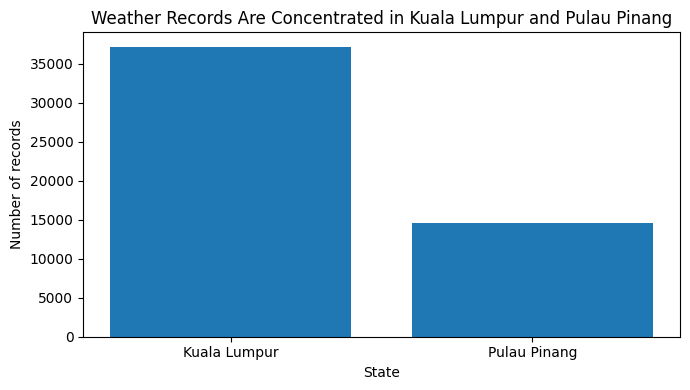

In [8]:
location_cols = [col for col in ["state", "city", "place"] if col in weather.columns]

for col in location_cols:
    print(f"\nValue counts for {col}:")
    display(weather[col].value_counts().head(20))

if "state" in weather.columns:
    state_counts = weather["state"].value_counts()
    plt.figure(figsize=(7, 4))
    plt.bar(state_counts.index.astype(str), state_counts.values)
    plt.title("Weather Records Are Concentrated in Kuala Lumpur and Pulau Pinang")
    plt.xlabel("State")
    plt.ylabel("Number of records")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

### Unusual Values Check

Some weather variables may contain rare or unusual values. These are checked because they may affect visualisations and interpretation. Extreme values are not automatically removed because they may represent rare weather events, but they should be discussed carefully.

In [9]:
display(weather[available_weather_cols_clean].describe().T)

unusual_checks = {}
if "humidity" in weather.columns:
    unusual_checks["humidity equal to 0"] = (weather["humidity"] == 0).sum()
if "uv_index" in weather.columns:
    unusual_checks["uv_index greater than 11"] = (weather["uv_index"] > 11).sum()
if "precipitation_rate" in weather.columns:
    unusual_checks["precipitation_rate greater than 100"] = (weather["precipitation_rate"] > 100).sum()
if "gust" in weather.columns:
    unusual_checks["gust greater than 30"] = (weather["gust"] > 30).sum()
if "wind_speed" in weather.columns:
    unusual_checks["wind_speed greater than 20"] = (weather["wind_speed"] > 20).sum()

unusual_summary = pd.DataFrame({
    "Check": list(unusual_checks.keys()),
    "Count": list(unusual_checks.values())
})
display(unusual_summary)

,count,mean,std,min,25%,50%,75%,max
temperature,51693.0,28.013987,3.098607,17.80,25.60,27.3,30.30,41.00
pressure,51693.0,1010.199369,4.273440,996.95,1007.45,1010.5,1013.24,1023.23
dew_point,51693.0,24.300320,1.848328,7.70,23.40,24.2,25.00,32.20
humidity,51693.0,82.022445,13.401809,0.00,72.80,84.4,93.00,100.00
wind_speed,51693.0,2.348674,3.443584,0.00,0.00,1.0,3.30,33.80
gust,51693.0,4.052621,7.641579,0.00,0.00,1.8,4.40,59.00
wind_chill,51693.0,28.011882,3.096055,17.80,25.60,27.3,30.30,41.00
uv_index,51693.0,1.319241,2.457270,0.00,0.00,0.0,2.00,16.00
precipitation_rate,51693.0,0.309495,3.791210,0.00,0.00,0.0,0.00,432.59
precipitation_total,51693.0,2.815153,10.341711,0.00,0.00,0.0,0.20,162.81


,Check,Count
0,humidity equal to 0,27
1,uv_index greater than 11,235
2,precipitation_rate greater than 100,9
3,gust greater than 30,1364
4,wind_speed greater than 20,116


### Short Conclusion: Data Cleaning

The cleaned dataset is suitable for analysis because duplicate rows, missing values, datetime fields, location coverage and unusual values have been checked. However, several raw variables had missing values, the dataset covers only selected locations in Kuala Lumpur and Pulau Pinang, and some unusual values remain. These limitations should be considered when interpreting results.

## 7. Preprocessing

This project does not require complex preprocessing such as scaling or encoding for advanced machine learning. The main preprocessing decisions are:

- using relative file paths;
- validating or creating `datetime`;
- using cleaned data for the main analysis;
- creating variable-specific subsets for each research question;
- keeping location and time variables available for grouping;
- using derived variables to make weather indicators more interpretable.

In [10]:
# Ensure relevant variables are numeric where needed
for col in available_weather_cols_clean:
    weather[col] = pd.to_numeric(weather[col], errors="coerce")

print("Numeric conversion completed for main weather columns.")
display(weather[available_weather_cols_clean].dtypes)

Numeric conversion completed for main weather columns.


temperature            float64
pressure               float64
dew_point              float64
humidity               float64
wind_speed             float64
gust                   float64
wind_chill             float64
uv_index               float64
precipitation_rate     float64
precipitation_total    float64
dtype: object

## 8. Feature Engineering

Feature engineering helps connect raw weather measurements to the project aim. The new variables below support the analysis of public communication value.

In [11]:
# Temperature vs wind chill
if {"temperature", "wind_chill"}.issubset(weather.columns):
    weather["temperature_difference"] = weather["temperature"] - weather["wind_chill"]

# Wind speed vs gust
if {"gust", "wind_speed"}.issubset(weather.columns):
    weather["gust_difference"] = weather["gust"] - weather["wind_speed"]

# Rain event
if "precipitation_total" in weather.columns:
    weather["rain_event"] = weather["precipitation_total"] > 0

# Pressure change, calculated within place if available
if {"pressure", "datetime"}.issubset(weather.columns):
    sort_cols = []
    if "place" in weather.columns:
        sort_cols.append("place")
    sort_cols.append("datetime")
    weather = weather.sort_values(sort_cols)
    if "place" in weather.columns:
        weather["pressure_change"] = weather.groupby("place")["pressure"].diff()
    else:
        weather["pressure_change"] = weather["pressure"].diff()
    weather["falling_pressure"] = weather["pressure_change"] < 0

# UV categories
def classify_uv(value):
    if pd.isna(value):
        return np.nan
    if value <= 2:
        return "Low"
    elif value <= 5:
        return "Moderate"
    elif value <= 7:
        return "High"
    elif value <= 10:
        return "Very High"
    else:
        return "Extreme"

if "uv_index" in weather.columns:
    weather["uv_category"] = weather["uv_index"].apply(classify_uv)
    weather["high_uv"] = weather["uv_index"] >= 6

engineered_cols = [
    col for col in [
        "temperature_difference", "gust_difference", "rain_event",
        "pressure_change", "falling_pressure", "uv_category", "high_uv"
    ] if col in weather.columns
]

print("Engineered columns created:")
print(engineered_cols)
display(weather[engineered_cols].head())

Engineered columns created:
['temperature_difference', 'gust_difference', 'rain_event', 'pressure_change', 'falling_pressure', 'uv_category', 'high_uv']


,temperature_difference,gust_difference,rain_event,pressure_change,falling_pressure,uv_category,high_uv
0,0.0,0.0,True,NaN,False,Low,False
1,0.0,0.0,True,0.68,False,Low,False
2,0.0,0.0,True,0.50,False,Low,False
3,0.0,0.0,True,0.34,False,Low,False
4,0.0,0.0,False,0.85,False,Low,False


### Short Conclusion: Feature Engineering

The engineered variables help translate raw weather measurements into more useful public communication indicators. For example, `temperature_difference` and `gust_difference` show whether technical indicators add information beyond common indicators, while `uv_category` translates UV index values into public warning categories.

### Note on `pressure_change` Missing Values

Although the main weather measurement columns contain no missing values in the final cleaned dataset, `pressure_change` may contain missing values for the first record of each place because there is no previous pressure observation for comparison. These missing values are expected and are not treated as data cleaning errors.


## 9. Preliminary Analysis / Exploratory Data Analysis (EDA)

This section performs EDA linked to the research questions. The goal is not to create many unrelated graphs, but to use visualisations and summary statistics that support the final client recommendations.

### 9.1 Dataset-Level EDA

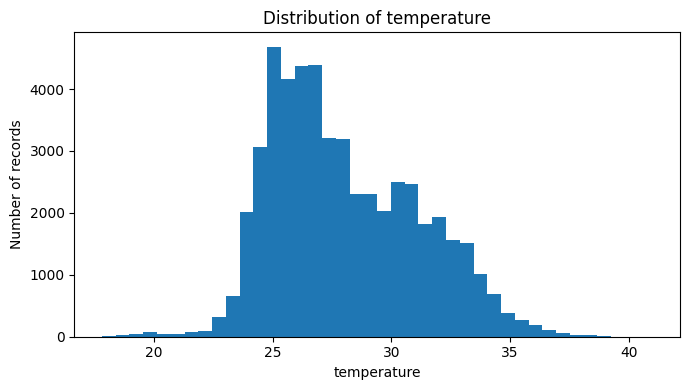

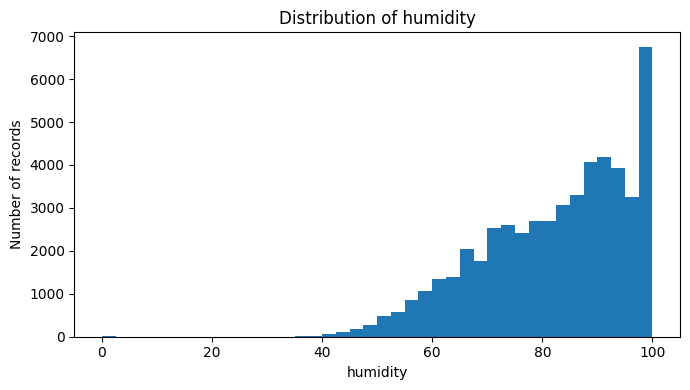

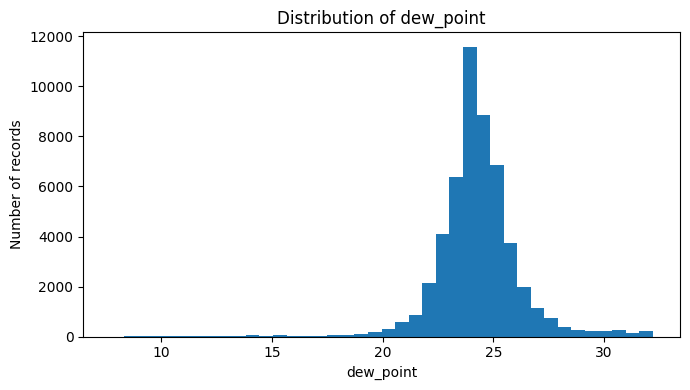

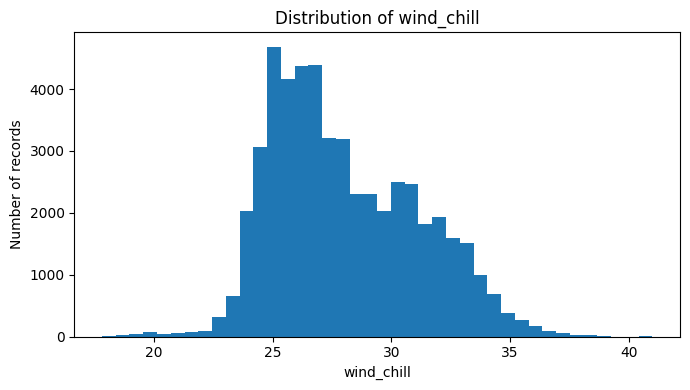

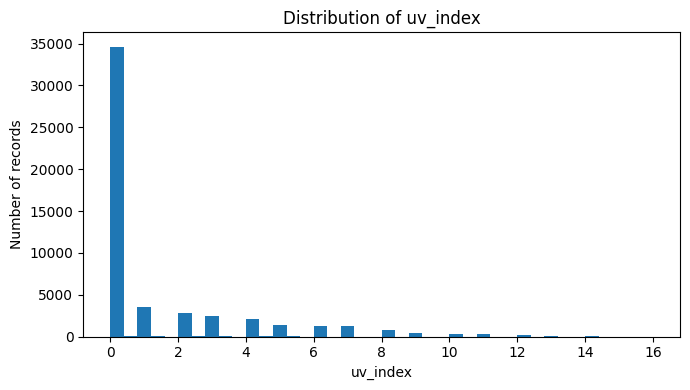

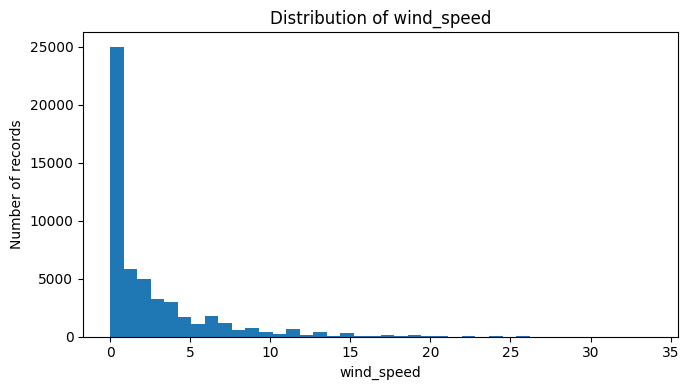

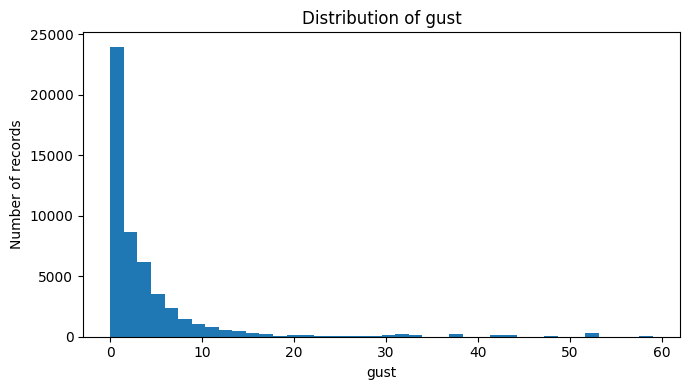

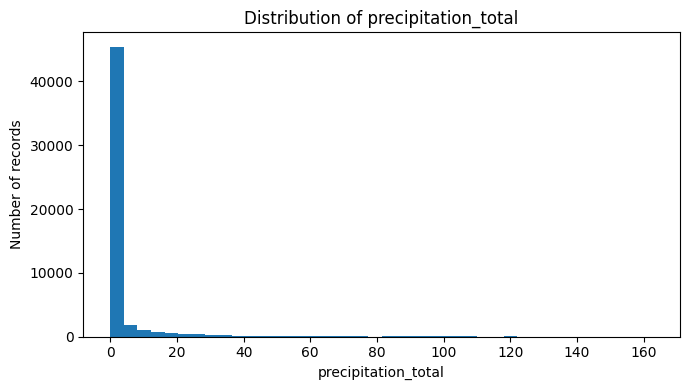

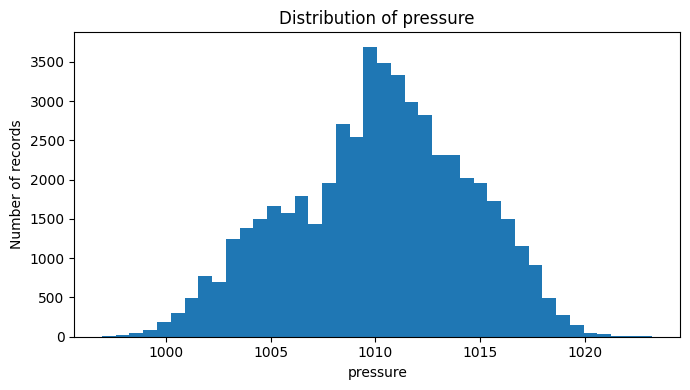

In [12]:
# Basic distributions for key variables
key_plot_cols = [col for col in ["temperature", "humidity", "dew_point", "wind_chill", "uv_index", "wind_speed", "gust", "precipitation_total", "pressure"] if col in weather.columns]

for col in key_plot_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(weather[col].dropna(), bins=40)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of records")
    plt.tight_layout()
    plt.show()

### 9.2 Outdoor Comfort EDA: Temperature and Wind Chill

,Metric,Value
0,Valid rows,51693.000000
1,Mean temperature,28.013987
2,Mean wind chill,28.011882
3,Mean temperature difference,0.002106
4,Median temperature difference,0.000000
5,Correlation,0.999420


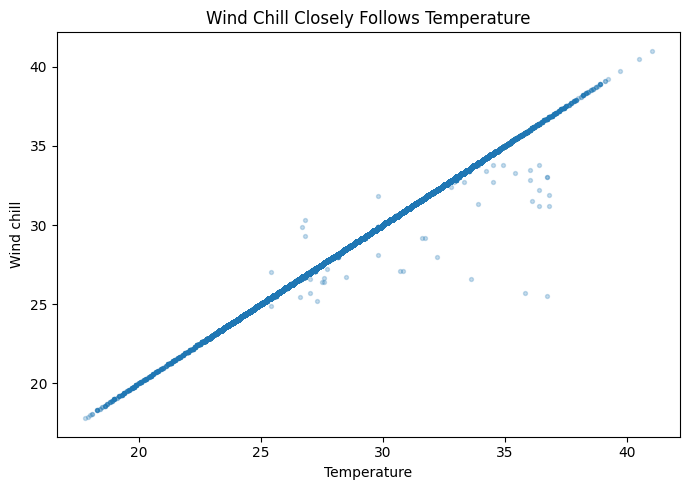

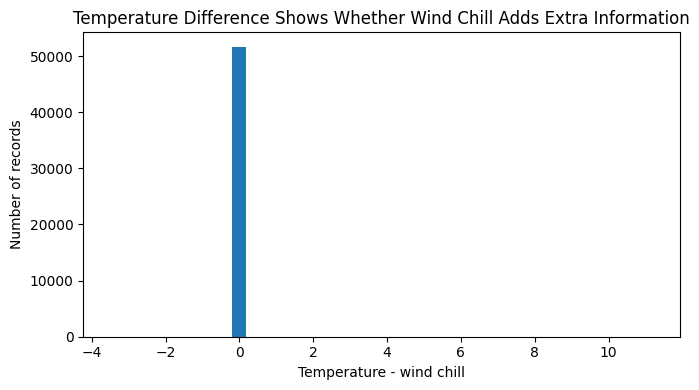

In [13]:
comfort_temp = weather[["temperature", "wind_chill", "temperature_difference"]].dropna().copy()

temp_wind_corr = comfort_temp["temperature"].corr(comfort_temp["wind_chill"])

temp_wind_summary = pd.DataFrame({
    "Metric": [
        "Valid rows",
        "Mean temperature",
        "Mean wind chill",
        "Mean temperature difference",
        "Median temperature difference",
        "Correlation"
    ],
    "Value": [
        len(comfort_temp),
        comfort_temp["temperature"].mean(),
        comfort_temp["wind_chill"].mean(),
        comfort_temp["temperature_difference"].mean(),
        comfort_temp["temperature_difference"].median(),
        temp_wind_corr
    ]
})
display(temp_wind_summary)

plt.figure(figsize=(7, 5))
plt.scatter(comfort_temp["temperature"], comfort_temp["wind_chill"], alpha=0.25, s=8)
plt.title("Wind Chill Closely Follows Temperature")
plt.xlabel("Temperature")
plt.ylabel("Wind chill")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(comfort_temp["temperature_difference"], bins=40)
plt.title("Temperature Difference Shows Whether Wind Chill Adds Extra Information")
plt.xlabel("Temperature - wind chill")
plt.ylabel("Number of records")
plt.tight_layout()
plt.show()

### Short Conclusion: Temperature and Wind Chill

Temperature and wind chill are closely related. In Malaysia's tropical context, wind chill appears to add limited extra value for routine public communication. Temperature should be prioritised as the main public-facing comfort indicator.

### 9.3 Outdoor Comfort EDA: Humidity and Dew Point

,Metric,Value
0,Valid rows,51693.000000
1,Mean humidity,82.022445
2,Mean dew point,24.300320
3,Correlation,0.284249


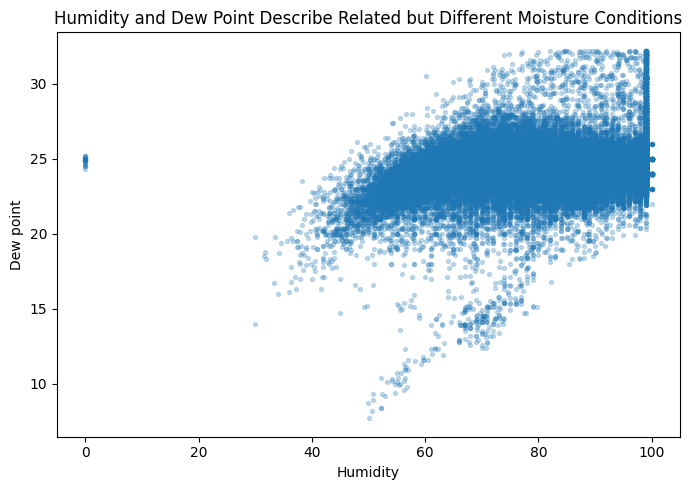

In [14]:
comfort_moisture = weather[["humidity", "dew_point"]].dropna().copy()

humidity_dew_corr = comfort_moisture["humidity"].corr(comfort_moisture["dew_point"])

humidity_dew_summary = pd.DataFrame({
    "Metric": [
        "Valid rows",
        "Mean humidity",
        "Mean dew point",
        "Correlation"
    ],
    "Value": [
        len(comfort_moisture),
        comfort_moisture["humidity"].mean(),
        comfort_moisture["dew_point"].mean(),
        humidity_dew_corr
    ]
})
display(humidity_dew_summary)

plt.figure(figsize=(7, 5))
plt.scatter(comfort_moisture["humidity"], comfort_moisture["dew_point"], alpha=0.25, s=8)
plt.title("Humidity and Dew Point Describe Related but Different Moisture Conditions")
plt.xlabel("Humidity")
plt.ylabel("Dew point")
plt.tight_layout()
plt.show()

,month,humidity,dew_point
0,Apr,82.359061,24.903277
1,Aug,82.789428,24.492306
2,Dec,83.119222,23.820166
3,Feb,79.573265,23.437905
4,Jan,81.451916,23.518682
5,Jul,81.899819,24.595362
6,Jun,81.578594,24.499767
7,Mar,80.081337,24.213607
8,May,80.406672,24.892711
9,Nov,85.662868,24.502801


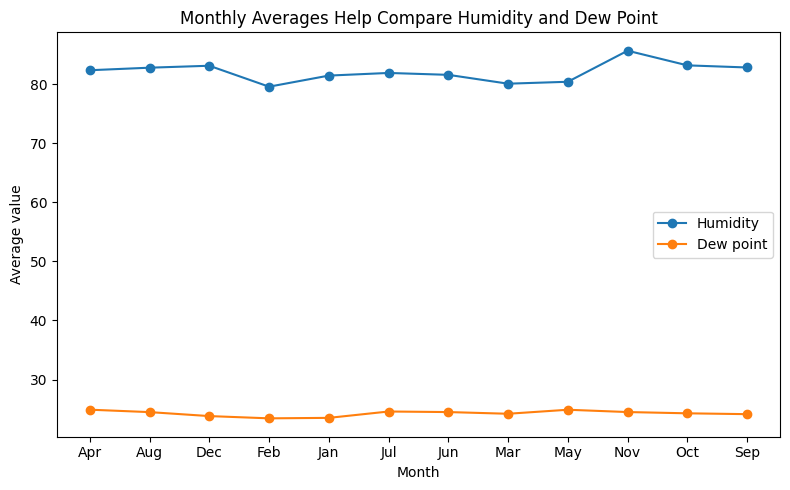

In [15]:
# Monthly pattern for humidity and dew point
if "month" in weather.columns:
    monthly_moisture = weather.groupby("month")[["humidity", "dew_point"]].mean().reset_index()
    display(monthly_moisture)

    plt.figure(figsize=(8, 5))
    plt.plot(monthly_moisture["month"], monthly_moisture["humidity"], marker="o", label="Humidity")
    plt.plot(monthly_moisture["month"], monthly_moisture["dew_point"], marker="o", label="Dew point")
    plt.title("Monthly Averages Help Compare Humidity and Dew Point")
    plt.xlabel("Month")
    plt.ylabel("Average value")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Short Conclusion: Humidity and Dew Point

Humidity and dew point are related moisture indicators, but they are not equally easy for the public to interpret. Humidity is more familiar and should be used for public comfort messages. Dew point can provide supporting technical context for muggy or oppressive conditions.

### 9.4 Rainfall EDA: Pressure and Precipitation

,Metric,Value
0,Valid rows,51693.000000
1,Mean pressure,1010.199369
2,Mean precipitation total,2.815153
3,Rain event rate,0.258700
4,Correlation: pressure vs precipitation total,0.046233
5,Correlation: pressure change vs precipitation ...,0.030164


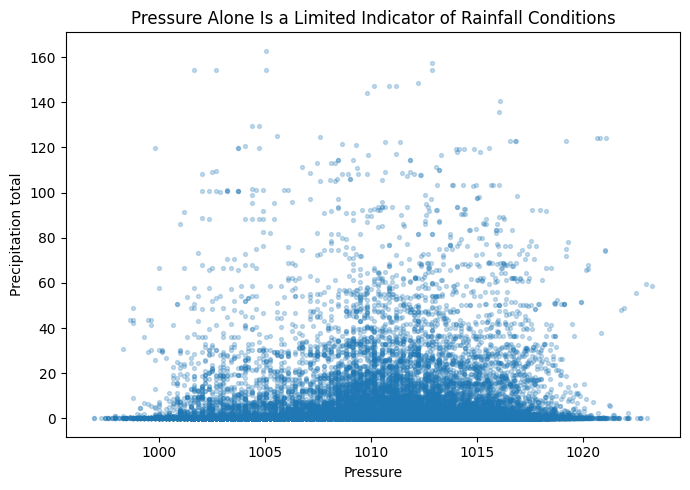

In [16]:
rainfall = weather[["pressure", "pressure_change", "falling_pressure", "precipitation_rate", "precipitation_total", "rain_event"]].dropna(subset=["pressure", "precipitation_total"]).copy()

rainfall_summary = pd.DataFrame({
    "Metric": [
        "Valid rows",
        "Mean pressure",
        "Mean precipitation total",
        "Rain event rate",
        "Correlation: pressure vs precipitation total",
        "Correlation: pressure change vs precipitation total"
    ],
    "Value": [
        len(rainfall),
        rainfall["pressure"].mean(),
        rainfall["precipitation_total"].mean(),
        rainfall["rain_event"].mean(),
        rainfall["pressure"].corr(rainfall["precipitation_total"]),
        rainfall[["pressure_change", "precipitation_total"]].dropna()["pressure_change"].corr(
            rainfall[["pressure_change", "precipitation_total"]].dropna()["precipitation_total"]
        )
    ]
})
display(rainfall_summary)

plt.figure(figsize=(7, 5))
plt.scatter(rainfall["pressure"], rainfall["precipitation_total"], alpha=0.25, s=8)
plt.title("Pressure Alone Is a Limited Indicator of Rainfall Conditions")
plt.xlabel("Pressure")
plt.ylabel("Precipitation total")
plt.tight_layout()
plt.show()

,pressure_group,rain_event,rain_event_percentage
0,"(996.9490000000001, 1007.45]",0.202196,20.219614
1,"(1007.45, 1010.5]",0.270096,27.009598
2,"(1010.5, 1013.24]",0.283249,28.324923
3,"(1013.24, 1023.23]",0.281439,28.143945


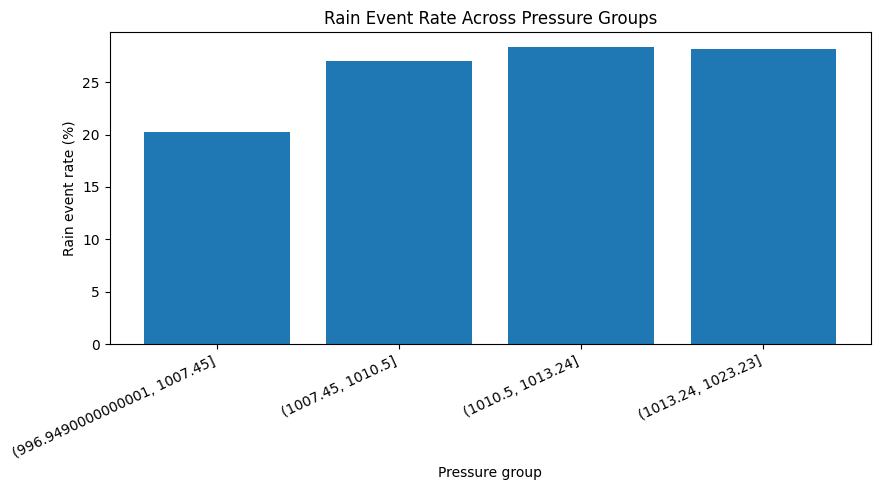

In [17]:
# Rain event rate by pressure group
rainfall["pressure_group"] = pd.qcut(rainfall["pressure"], q=4, duplicates="drop")
rain_event_by_pressure = rainfall.groupby("pressure_group", observed=False)["rain_event"].mean().reset_index()
rain_event_by_pressure["rain_event_percentage"] = rain_event_by_pressure["rain_event"] * 100
display(rain_event_by_pressure)

plt.figure(figsize=(9, 5))
plt.bar(rain_event_by_pressure["pressure_group"].astype(str), rain_event_by_pressure["rain_event_percentage"])
plt.title("Rain Event Rate Across Pressure Groups")
plt.xlabel("Pressure group")
plt.ylabel("Rain event rate (%)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

### Short Conclusion: Pressure and Precipitation

Pressure may provide background context for rainfall, but it is not direct enough to use alone as a public rainfall warning. Precipitation-related measures are clearer and more actionable for public communication.

### 9.5 Wind EDA: Wind Speed and Gust

,Metric,Value
0,Valid rows,51693.000000
1,Mean wind speed,2.348674
2,Mean gust,4.052621
3,Mean gust difference,1.703947
4,Median gust difference,0.500000
5,Correlation: wind speed vs gust,0.600116
6,High gust threshold (90th percentile),9.400000


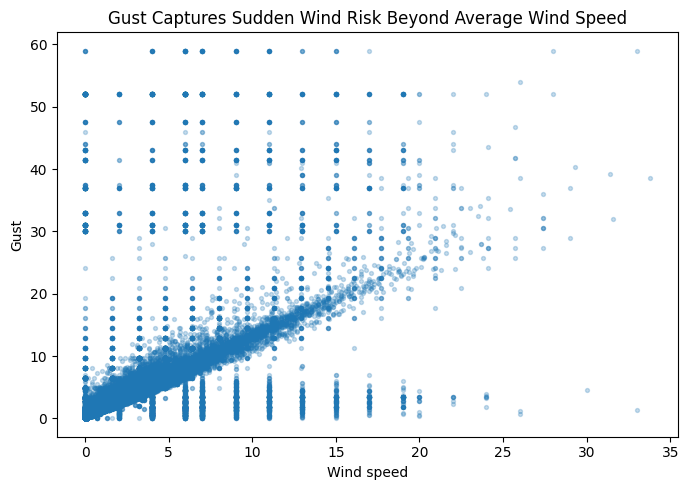

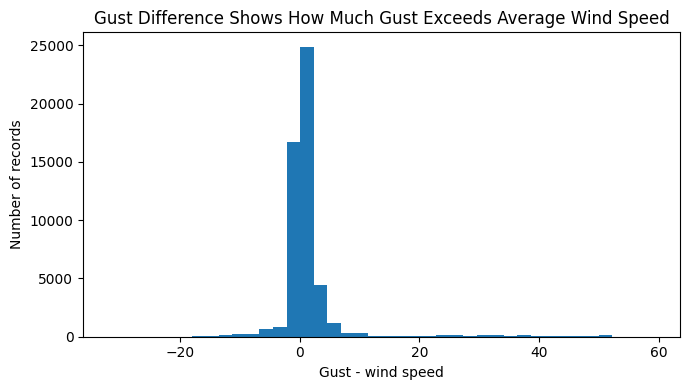

In [18]:
wind = weather[["wind_speed", "gust", "gust_difference"]].dropna().copy()

high_gust_threshold = wind["gust"].quantile(0.90)
wind["high_gust_event"] = wind["gust"] >= high_gust_threshold

wind_summary = pd.DataFrame({
    "Metric": [
        "Valid rows",
        "Mean wind speed",
        "Mean gust",
        "Mean gust difference",
        "Median gust difference",
        "Correlation: wind speed vs gust",
        "High gust threshold (90th percentile)"
    ],
    "Value": [
        len(wind),
        wind["wind_speed"].mean(),
        wind["gust"].mean(),
        wind["gust_difference"].mean(),
        wind["gust_difference"].median(),
        wind["wind_speed"].corr(wind["gust"]),
        high_gust_threshold
    ]
})
display(wind_summary)

plt.figure(figsize=(7, 5))
plt.scatter(wind["wind_speed"], wind["gust"], alpha=0.25, s=8)
plt.title("Gust Captures Sudden Wind Risk Beyond Average Wind Speed")
plt.xlabel("Wind speed")
plt.ylabel("Gust")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(wind["gust_difference"], bins=40)
plt.title("Gust Difference Shows How Much Gust Exceeds Average Wind Speed")
plt.xlabel("Gust - wind speed")
plt.ylabel("Number of records")
plt.tight_layout()
plt.show()

### Short Conclusion: Wind Speed and Gust

Wind speed describes general wind conditions, while gust captures sudden increases in wind strength. Gust should be communicated separately when sudden wind risk is relevant to outdoor users or transport safety.

### 9.6 UV EDA: UV Index and Public Warning Categories

,Metric,Value
0,Valid UV rows,51693.000000
1,Mean UV index,1.319241
2,Median UV index,0.000000
3,Maximum UV index,16.000000
4,High UV rate (UV >= 6),0.087555
5,Very high or extreme UV rate (UV >= 8),0.039793
6,Extreme UV rate (UV >= 11),0.009653


,record_count
uv_category,
Low,41011
Moderate,6119
High,2506
Very High,1558
Extreme,499


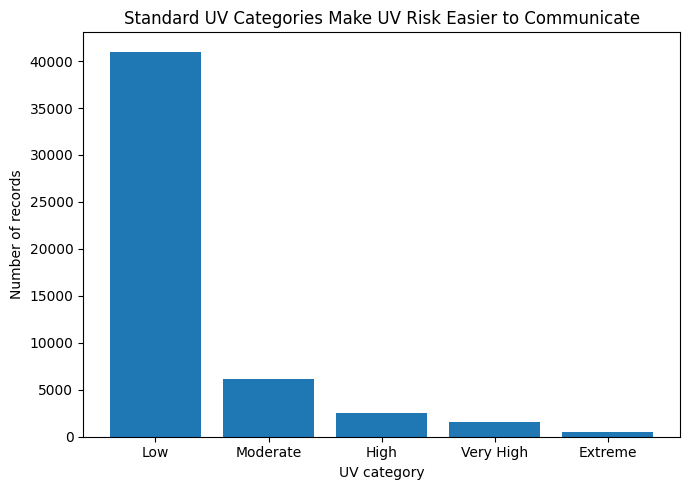

In [19]:
uv = weather[["uv_index", "uv_category", "high_uv", "hour", "month"]].dropna(subset=["uv_index"]).copy()

uv_category_order = ["Low", "Moderate", "High", "Very High", "Extreme"]
uv_category_counts = uv["uv_category"].value_counts().reindex(uv_category_order).fillna(0).astype(int)

uv_summary = pd.DataFrame({
    "Metric": [
        "Valid UV rows",
        "Mean UV index",
        "Median UV index",
        "Maximum UV index",
        "High UV rate (UV >= 6)",
        "Very high or extreme UV rate (UV >= 8)",
        "Extreme UV rate (UV >= 11)"
    ],
    "Value": [
        len(uv),
        uv["uv_index"].mean(),
        uv["uv_index"].median(),
        uv["uv_index"].max(),
        (uv["uv_index"] >= 6).mean(),
        (uv["uv_index"] >= 8).mean(),
        (uv["uv_index"] >= 11).mean()
    ]
})
display(uv_summary)
display(uv_category_counts.to_frame("record_count"))

plt.figure(figsize=(7, 5))
plt.bar(uv_category_counts.index, uv_category_counts.values)
plt.title("Standard UV Categories Make UV Risk Easier to Communicate")
plt.xlabel("UV category")
plt.ylabel("Number of records")
plt.tight_layout()
plt.show()

,hour,uv_index
0,0,0.030636
1,1,0.100812
2,2,0.168741
3,3,0.282342
4,4,0.313039
5,5,0.217227
6,6,0.240553
7,7,0.286501
8,8,0.638838
9,9,1.570291


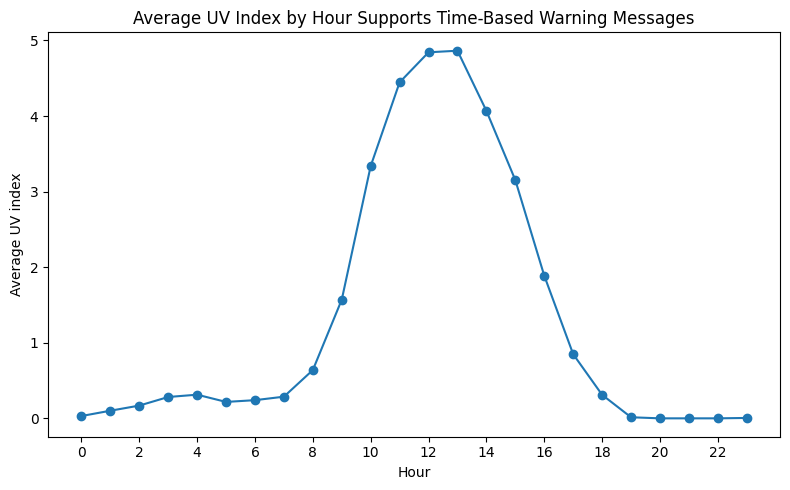

,month,high_uv,high_uv_percentage
0,Apr,0.091631,9.163076
1,Aug,0.082558,8.255814
2,Dec,0.070745,7.074522
3,Feb,0.122879,12.287918
4,Jan,0.087708,8.770764
5,Jul,0.070433,7.043329
6,Jun,0.080153,8.015267
7,Mar,0.117195,11.719478
8,May,0.087335,8.733532
9,Nov,0.069179,6.917914


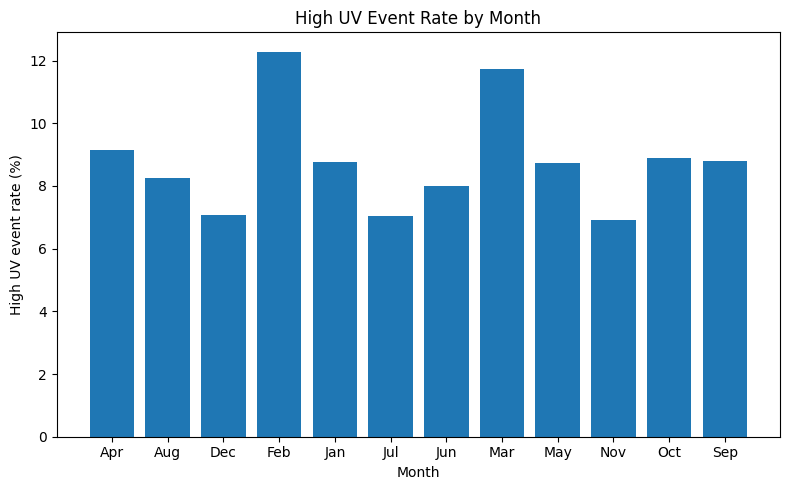

In [20]:
uv_by_hour = uv.groupby("hour")["uv_index"].mean().reset_index()
display(uv_by_hour)

plt.figure(figsize=(8, 5))
plt.plot(uv_by_hour["hour"], uv_by_hour["uv_index"], marker="o")
plt.title("Average UV Index by Hour Supports Time-Based Warning Messages")
plt.xlabel("Hour")
plt.ylabel("Average UV index")
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

uv_by_month = uv.groupby("month")["high_uv"].mean().reset_index()
uv_by_month["high_uv_percentage"] = uv_by_month["high_uv"] * 100
display(uv_by_month)

plt.figure(figsize=(8, 5))
plt.bar(uv_by_month["month"].astype(str), uv_by_month["high_uv_percentage"])
plt.title("High UV Event Rate by Month")
plt.xlabel("Month")
plt.ylabel("High UV event rate (%)")
plt.tight_layout()
plt.show()

### Short Conclusion: UV Index

UV index is one of the strongest public-facing indicators because it can be communicated through standard categories. These categories are easy to connect with public action advice, such as seeking shade or reducing direct sun exposure.

## 10. Conclusions from EDA

The EDA supports the following early conclusions:

1. **Temperature is clearer than wind chill** for routine outdoor comfort messages.
2. **Humidity is easier to communicate than dew point**, while dew point can support technical interpretation of muggy conditions.
3. **Precipitation is clearer than pressure** for public rainfall communication.
4. **Gust adds warning value beyond wind speed** because it captures sudden wind increases.
5. **UV index is highly suitable for public warnings** because it can be translated into standard risk categories.

These insights guide the final analysis and recommendations.

## 11. Modeling / Analysis

This project does not require complex machine learning to answer the client problem. Instead, the analysis uses appropriate statistical and indicator-based methods:

- correlation analysis;
- difference analysis;
- grouped rain-event analysis;
- UV category classification;
- high-risk event rates.

These methods are suitable because the client needs clear communication recommendations, not a highly complex predictive model.

In [21]:
analysis_methods = pd.DataFrame({
    "Research area": [
        "Temperature vs wind chill",
        "Humidity vs dew point",
        "Pressure vs precipitation",
        "Wind speed vs gust",
        "UV index"
    ],
    "Method used": [
        "Correlation and temperature difference",
        "Correlation and monthly comparison",
        "Correlation and rain event rate by pressure group",
        "Correlation and gust difference",
        "UV category classification and high UV rates"
    ],
    "Reason for method": [
        "Tests whether wind chill adds information beyond temperature.",
        "Compares public familiarity and technical moisture indicators.",
        "Tests whether pressure supports rainfall communication.",
        "Tests whether gust adds sudden-risk information beyond wind speed.",
        "Translates raw UV values into public warning categories."
    ]
})
display(analysis_methods)

,Research area,Method used,Reason for method
0,Temperature vs wind chill,Correlation and temperature difference,Tests whether wind chill adds information beyo...
1,Humidity vs dew point,Correlation and monthly comparison,Compares public familiarity and technical mois...
2,Pressure vs precipitation,Correlation and rain event rate by pressure group,Tests whether pressure supports rainfall commu...
3,Wind speed vs gust,Correlation and gust difference,Tests whether gust adds sudden-risk informatio...
4,UV index,UV category classification and high UV rates,Translates raw UV values into public warning c...


## 12. Model / Analysis Conclusions

The analysis methods show that simple, interpretable indicators are most useful for this client. The project therefore prioritises **actionable public communication** rather than technical complexity.

### Analysis Conclusions by Theme

| Theme | Main conclusion |
|---|---|
| Outdoor comfort | Temperature and humidity should be prioritised for public-facing comfort messages. |
| Rainfall communication | Precipitation is clearer than pressure for public alerts. |
| Wind-related risk | Gust should be communicated separately when sudden wind risk matters. |
| UV exposure | UV index should be communicated using standard risk categories. |

These conclusions directly support the final recommendations.

## 13. Overall Conclusions

### Final Answer to the Main Research Question

The most useful weather indicators for public communication are:

- **temperature** and **humidity** for outdoor comfort;
- **precipitation rate / total** for rainfall communication;
- **wind speed** and **gust** for general wind and sudden wind risk;
- **UV index** for UV exposure warnings.

More technical indicators such as **wind chill**, **dew point** and **pressure** may still be useful, but they should mainly be used as supporting or internal indicators.

In [22]:
final_recommendations = pd.DataFrame({
    "Indicator": [
        "Temperature",
        "Humidity",
        "Precipitation rate / total",
        "Wind speed",
        "Gust",
        "UV index",
        "Wind chill",
        "Dew point",
        "Pressure"
    ],
    "Public communication value": [
        "High",
        "High",
        "High",
        "High",
        "High",
        "High",
        "Low / Medium",
        "Medium",
        "Low / Medium"
    ],
    "Recommended use": [
        "Use as a main comfort indicator.",
        "Use for public comfort and oppressive-weather messages.",
        "Use directly for rainfall alerts and outdoor planning messages.",
        "Use for general wind condition communication.",
        "Use for sudden wind risk warnings.",
        "Use standard UV categories for public warning messages.",
        "Use only when meaningfully different from temperature.",
        "Use as a supporting technical indicator for discomfort.",
        "Use internally or as supporting rainfall-risk context, not as a standalone public warning."
    ]
})
display(final_recommendations)

,Indicator,Public communication value,Recommended use
0,Temperature,High,Use as a main comfort indicator.
1,Humidity,High,Use for public comfort and oppressive-weather ...
2,Precipitation rate / total,High,Use directly for rainfall alerts and outdoor p...
3,Wind speed,High,Use for general wind condition communication.
4,Gust,High,Use for sudden wind risk warnings.
5,UV index,High,Use standard UV categories for public warning ...
6,Wind chill,Low / Medium,Use only when meaningfully different from temp...
7,Dew point,Medium,Use as a supporting technical indicator for di...
8,Pressure,Low / Medium,Use internally or as supporting rainfall-risk ...


In [23]:
poster_summary = pd.DataFrame({
    "Communication area": [
        "Outdoor comfort",
        "Rainfall communication",
        "Wind-related risk",
        "UV exposure"
    ],
    "Best public-facing indicators": [
        "Temperature, humidity",
        "Precipitation rate / total",
        "Wind speed, gust",
        "UV index categories"
    ],
    "Supporting indicators": [
        "Wind chill, dew point",
        "Pressure",
        "Pressure or broader weather context",
        "Temperature, hour or month patterns"
    ],
    "Client action": [
        "Use simple comfort messages.",
        "Use direct rainfall alerts.",
        "Use gust warnings for sudden wind risk.",
        "Use standard UV warning categories."
    ]
})
display(poster_summary)

,Communication area,Best public-facing indicators,Supporting indicators,Client action
0,Outdoor comfort,"Temperature, humidity","Wind chill, dew point",Use simple comfort messages.
1,Rainfall communication,Precipitation rate / total,Pressure,Use direct rainfall alerts.
2,Wind-related risk,"Wind speed, gust",Pressure or broader weather context,Use gust warnings for sudden wind risk.
3,UV exposure,UV index categories,"Temperature, hour or month patterns",Use standard UV warning categories.


## 14. Limitations

The findings should be interpreted carefully because of the following limitations:

1. **Limited geographic coverage**  
   The dataset covers selected locations in Kuala Lumpur and Pulau Pinang only. It should not be treated as representative of all Malaysia.

2. **Missing values in the raw dataset**  
   Several important variables had missing values in the raw data. If values were imputed during cleaning, some patterns may partly reflect the cleaning method.

3. **Uneven location representation**  
   Some places have more records than others, which may affect summaries and comparisons.

4. **Data dictionary mismatch**  
   The data dictionary mentions air quality, but the CSV does not include air quality variables. This limits health-related weather communication analysis.

5. **Unusual values remain**  
   Some records include unusual values such as high UV index or extreme precipitation. These may represent rare events or measurement issues.

6. **Associations, not causation**  
   Correlation and grouped analysis identify associations, but they do not prove causal relationships.

7. **Public understanding was not directly tested**  
   Recommendations are based on data patterns and interpretability, not survey evidence from the public.

## 15. Future Work and Data Management Recommendations

This section strengthens the final client recommendations by separating future data improvement actions from the limitations.

### Data Management Recommendations

1. **Expand geographic coverage**  
   The current dataset covers selected locations in Kuala Lumpur and Pulau Pinang only. Future datasets should include more Malaysian states and more balanced location coverage.

2. **Reduce missing values in key warning variables**  
   Variables such as UV index, gust and precipitation-related measures had missing values in the raw data. These variables are important for public warning communication, so future collection should prioritise completeness.

3. **Keep imputation flag columns**  
   If missing values are filled, future datasets should preserve imputation flag columns such as `_was_imputed`. This helps analysts distinguish observed values from filled values.

4. **Standardise units and variable definitions**  
   Wind speed, gust, precipitation and pressure should have clearly documented units so that public-facing communication remains consistent.

5. **Add air quality variables**  
   The data dictionary mentions air quality, but the available CSV does not include air quality fields. Adding air quality would support broader public health-related weather communication.

### Future Data Science Approaches

1. **Build a public-facing weather dashboard**  
   A dashboard could present temperature, humidity, precipitation, wind speed, gust and UV categories using simple, action-oriented messages.

2. **Develop warning models with real-time data**  
   Future work could use real-time or forecast data to develop rainfall, UV and sudden wind warning models.

3. **Evaluate public understanding**  
   Surveys or user testing could identify whether the public understands humidity, dew point, gust, UV categories and other weather indicators.

4. **Compare locations and seasons**  
   A larger dataset could support more reliable seasonal and regional recommendations.


## 16. References

- ADS1001 Project Guidelines and Marking Rubric, Monash University Malaysia.
- ADS1001 Malaysia Weather Dataset supplied in the project folder.
- ADS1001 Weather Forecast Data Dictionary supplied in the project folder.
- Standard UV Index public risk categories:
  - 0–2 Low
  - 3–5 Moderate
  - 6–7 High
  - 8–10 Very High
  - 11+ Extreme


## Final Consistency Check with Individual Member Notebooks

This final group notebook is aligned with the five individual member notebooks:

- **Member 1 (LI YIMING):** client problem, project aim and research questions are used in Sections 1–2.
- **Member 2 (CHEN ZIMO):** data dictionary, data cleaning, imputation flags, location coverage and feature engineering are used in Sections 3 and 5–8.
- **Member 3 (HUANG QINGYUE):** outdoor comfort analysis is used in Sections 9.2–9.3 and the final recommendations.
- **Member 4 (TAY CHEN ZHE):** rainfall, wind/gust and UV warning analysis is used in Sections 9.4–9.6 and the final recommendations.
- **Member 5 (XU ZIHAO):** overall conclusions, recommendations, limitations and future work are used in Sections 13–15.

The main research question, recommendation table and limitations are consistent across the individual notebooks, the final notebook, the poster and the planned presentation.


## 17. Optional Appendix: Presentation and Poster Handoff

### Recommended Presentation Slides

1. Title and team  
2. Client problem and main research question  
3. Dataset overview  
4. Data cleaning and feature engineering  
5. Temperature vs wind chill  
6. Humidity vs dew point  
7. Pressure/precipitation and wind/gust  
8. UV index categories  
9. Overall indicator recommendations  
10. Limitations and future work  

### Recommended Poster Structure

- Title  
- Client problem  
- Main research question  
- Dataset overview  
- Cleaning summary  
- Key finding 1: outdoor comfort  
- Key finding 2: public warnings  
- Final recommendation table  
- Limitations and future work  

### Best figures to use

- Weather Records Are Concentrated in Kuala Lumpur and Pulau Pinang  
- Wind Chill Closely Follows Temperature  
- Gust Captures Sudden Wind Risk Beyond Average Wind Speed  
- Standard UV Categories Make UV Risk Easier to Communicate